# Sunrise Social Club: Exploratory Data Analysis

## Objective:
Analyze cafe sales data to understand product performance, customer behavior, and operational patterns across items, flavors, customization options, and time of day.

## Section 1: Loading the Data & Overview

In [182]:
#importing libraries
import numpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [183]:
#loading the data
df = pd.read_csv("../data/processed/sales_merged.csv")
df.head()

,Date,Time,Original_Item,Item,Base,Signature_Drink,Qty,Net_Sales,Size,Cold_Foam,Flavor,Avg_Temp,Weather_Condition,Event_Type,Location
0,2026-06-16,12:48:11,Matcha Latte,Matcha Latte,NaN,False,1.0,8.0,NaN,True,Strawberry,75,Cloudy,Market,First Flight
1,2026-06-16,12:38:43,Cold Brew,Cold Brew,Whole Milk,False,1.0,8.0,16oz,True,Salted Maple,75,Cloudy,Market,First Flight
2,2026-06-16,12:33:54,Matcha Latte,Matcha Latte,Whole Milk,False,2.0,16.0,12oz,True,Cinn Roll,75,Cloudy,Market,First Flight
3,2026-06-16,12:31:26,Lemonade,Lemonade,Lemonade,False,1.0,5.0,16oz,False,Strawberry,75,Cloudy,Market,First Flight
4,2026-06-16,12:31:26,Lemonade,Lemonade,Lemonade,False,1.0,4.0,12oz,False,Strawberry,75,Cloudy,Market,First Flight


Each row represents a single line-item transaction (not a full customer order). Orders may contain multiple items across multiple rows.

In [184]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797 entries, 0 to 796
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               797 non-null    object 
 1   Time               797 non-null    object 
 2   Original_Item      797 non-null    object 
 3   Item               797 non-null    object 
 4   Base               458 non-null    object 
 5   Signature_Drink    797 non-null    bool   
 6   Qty                797 non-null    float64
 7   Net_Sales          797 non-null    float64
 8   Size               576 non-null    object 
 9   Cold_Foam          797 non-null    bool   
 10  Flavor             631 non-null    object 
 11  Avg_Temp           797 non-null    int64  
 12  Weather_Condition  797 non-null    object 
 13  Event_Type         797 non-null    object 
 14  Location           797 non-null    object 
dtypes: bool(2), float64(2), int64(1), object(10)
memory usage: 82.6+ KB


,Qty,Net_Sales,Avg_Temp
count,797.000000,797.000000,797.000000
mean,1.129235,7.743312,80.963614
std,0.394193,4.700630,3.833525
min,1.000000,2.000000,75.000000
25%,1.000000,6.000000,79.000000
50%,1.000000,8.000000,82.000000
75%,1.000000,8.000000,84.000000
max,4.000000,75.000000,86.000000


### Exploring Missing Values:

In [185]:
df.isna().sum().sort_values(ascending=False)

Base                 339
Size                 221
Flavor               166
Date                   0
Time                   0
Original_Item          0
Item                   0
Signature_Drink        0
Qty                    0
Net_Sales              0
Cold_Foam              0
Avg_Temp               0
Weather_Condition      0
Event_Type             0
Location               0
dtype: int64

### Data Quality Notes:

Several fields contain missing values due to limitations or errors when operating the point-of-sale system.

- **Base** is missing for a subset of transactions. These values were retained as missing because the true base could not be determined reliably.
- **Size** is missing for some transactions. While size may be partially inferable from pricing, reconstructing it would require assumptions about add-ons and pricing rules, so missing values were retained.
- **Flavor** is missing for transactions where no flavor was added (e.g., plain Cold Brew, Matcha Latte, or Lemonade). These missing values represent valid non-selection rather than data entry errors.
- Core transaction fields (Date, Time, Item, Quantity, and Net Sales) **are** complete and serve as the primary basis for analysis.

In [186]:
df['Base']= df['Base'].fillna('Unknown')
df['Size']= df['Size'].fillna('Unknown')
df['Flavor']= df['Flavor'].fillna('No Syrup')

## Section 2: Business Performance Overview

### 2.1 Sales Overview

In [187]:
print(f'Total Net Sales: ${df["Net_Sales"].sum():,.2f}')
print(f'Total Quantity Sold: {df["Qty"].sum():,}')

Total Net Sales: $6,171.42
Total Quantity Sold: 900.0


In [188]:
df["Net_Sales"].describe()

count    797.000000
mean       7.743312
std        4.700630
min        2.000000
25%        6.000000
50%        8.000000
75%        8.000000
max       75.000000
Name: Net_Sales, dtype: float64

### 2.2 Customer Order Value

In [210]:
order_level = (
    df.groupby(["Date", "Time"])["Net_Sales"]
      .sum()
)

# Summary statistics
print(order_level.describe())

print(f"Average Order Value: ${order_level.mean():.2f}")
print(f"Median Order Value: ${order_level.median():.2f}")

count    540.000000
mean      11.428556
std        7.246497
min        2.000000
25%        8.000000
50%        9.000000
75%       14.000000
max       93.000000
Name: Net_Sales, dtype: float64
Average Order Value: $11.43
Median Order Value: $9.00


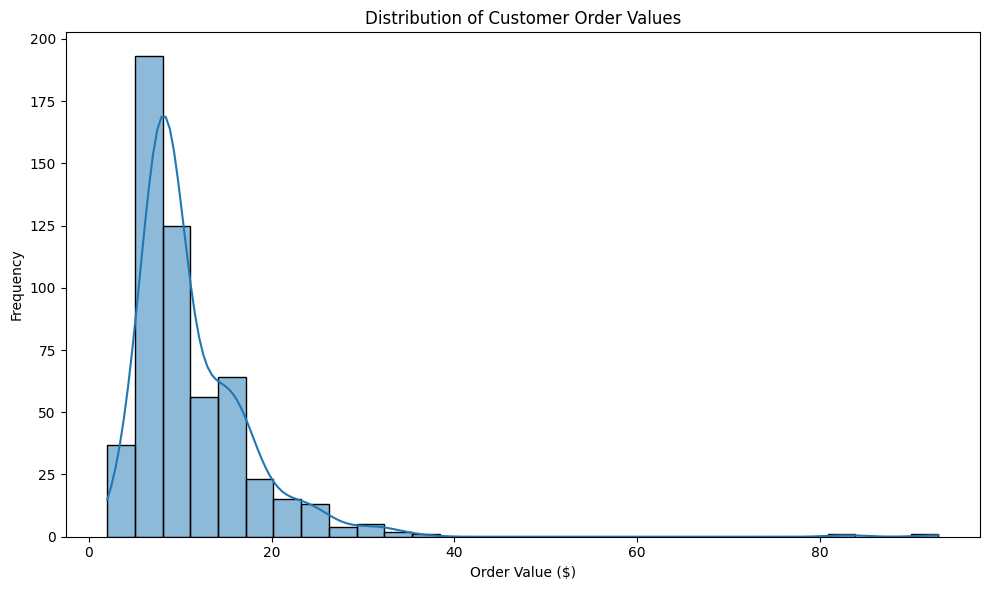

In [212]:
plt.figure(figsize=(10, 6))
sns.histplot(order_level, bins=30, kde=True)
plt.title("Distribution of Customer Order Values")
plt.xlabel("Order Value ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Most customer orders fall between $8 and $14, with an average order value of $11.43. A small number of larger purchases create a right-skewed distribution.

## Section 3: Product Performance
This section explores which products drive demand and revenue.

### 3.1 Revenue by Item

In [189]:
items_by_revenue = df.groupby('Item')['Net_Sales'].sum().sort_values(ascending=False)
items_by_revenue

Item
Matcha Latte    3597.42
Cold Brew       1556.00
Lemonade         724.00
Mug              150.00
Sticker          144.00
Name: Net_Sales, dtype: float64

### 3.2 Quantity by Item

In [190]:
items_by_quantity = df.groupby('Item')['Qty'].sum().sort_values(ascending=False)
items_by_quantity

Item
Matcha Latte    446.0
Cold Brew       218.0
Lemonade        162.0
Sticker          72.0
Mug               2.0
Name: Qty, dtype: float64

### 3.3 Revenue vs. Quantity

In [191]:
item_stats = df.groupby("Item").agg(
    Net_Sales=("Net_Sales", "sum"),
    Qty=("Qty", "sum")).abs().sort_values("Net_Sales", ascending=False)

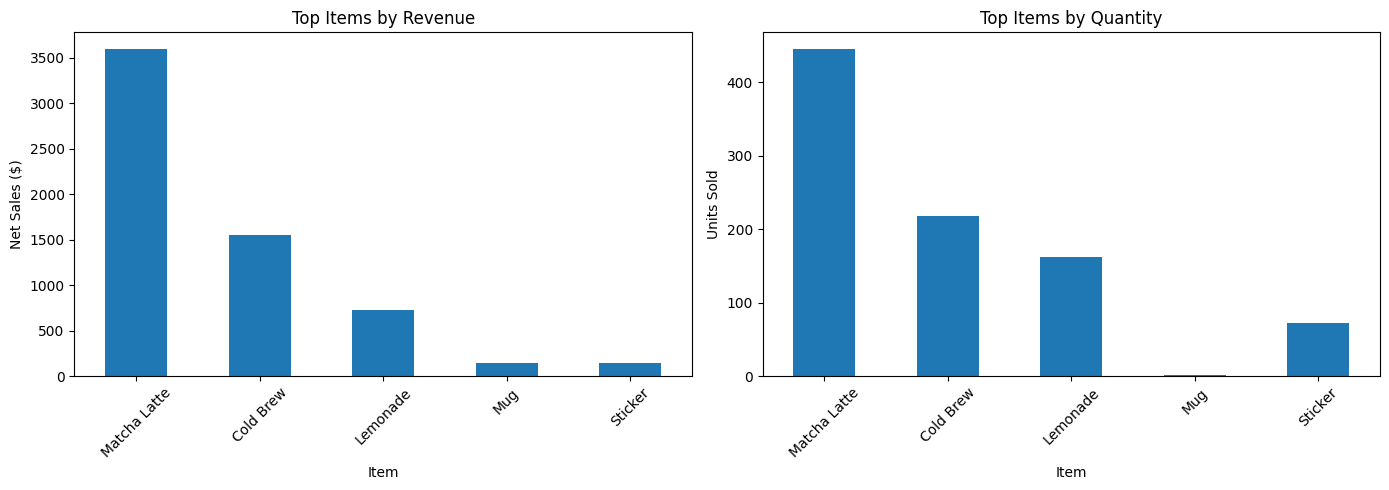

In [192]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue
item_stats["Net_Sales"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Top Items by Revenue")
axes[0].set_ylabel("Net Sales ($)")
axes[0].tick_params(axis='x', rotation=45)

# Quantity
item_stats["Qty"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Top Items by Quantity")
axes[1].set_ylabel("Units Sold")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

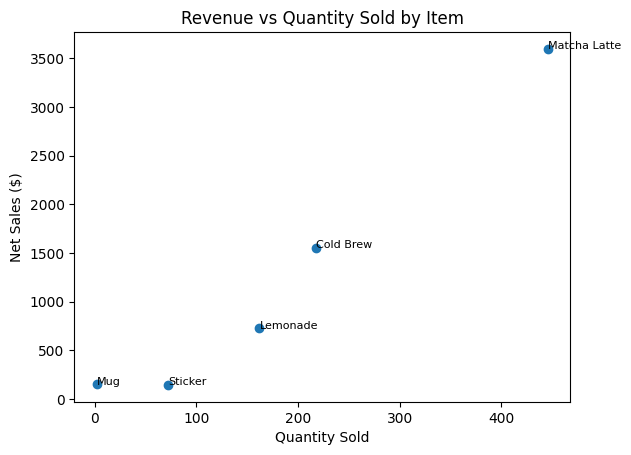

In [214]:
plt.scatter(item_stats["Qty"], item_stats["Net_Sales"])
plt.xlabel("Quantity Sold")
plt.ylabel("Net Sales ($)")
plt.title("Revenue vs Quantity Sold by Item")

for i in item_stats.index:
    plt.text(item_stats.loc[i, "Qty"], item_stats.loc[i, "Net_Sales"], i, fontsize=8)

plt.show()

- Matcha Latte dominates both revenue and quantity, indicating it is the core driver of both demand and sales.
- Cold Brew shows high volume but lower revenue efficiency compared to Matcha Latte, suggesting lower price per unit.
- Lemonade performs relatively well in quantity but contributes less revenue, reinforcing its role as a high-volume, lower-margin product.
- Merchandise items (Sticker, Mug) generate revenue despite low volume, highlighting their role as high-margin add-ons rather than core demand drivers.

## Section 4: Customer Preferences

In [230]:
# Filter dataset to only include drink items
drink_items = ["Matcha Latte", "Cold Brew", "Lemonade"]

drink_df = df[df["Item"].isin(drink_items)]

### 4.1 Flavor Popularity

In [225]:
flavor_stats = drink_df.groupby("Flavor").agg(
    Net_Sales=("Net_Sales", "sum"),
    Qty=("Qty", "sum")).abs().sort_values("Net_Sales", ascending=False)
flavor_stats

,Net_Sales,Qty
Flavor,,
Strawberry,2094.58,293.0
Blueberry,897.00,117.0
Salted Maple,864.66,112.0
No Syrup,758.18,131.0
Cinn Roll,480.00,61.0
Vanilla,447.00,60.0
Cake Batter,224.00,28.0
"Strawberry, Blueberry",112.00,24.0


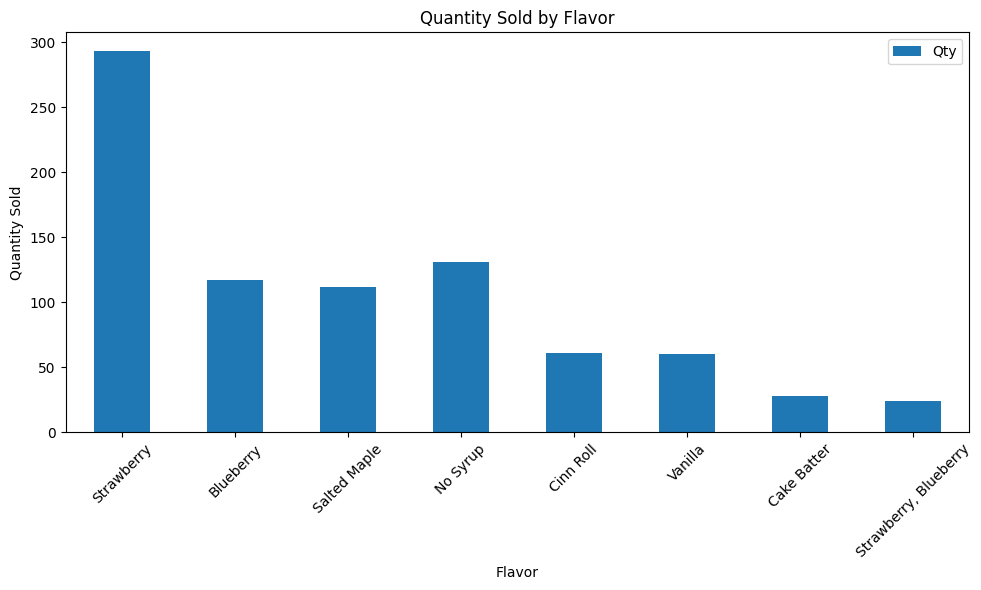

In [226]:
flavor_stats.plot(kind="bar", y="Qty", figsize=(10, 6))
plt.title("Quantity Sold by Flavor")
plt.ylabel("Quantity Sold")
plt.xlabel("Flavor")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Strawberry was the most frequently selected flavor, suggesting strong customer preference for fruit-based drinks.

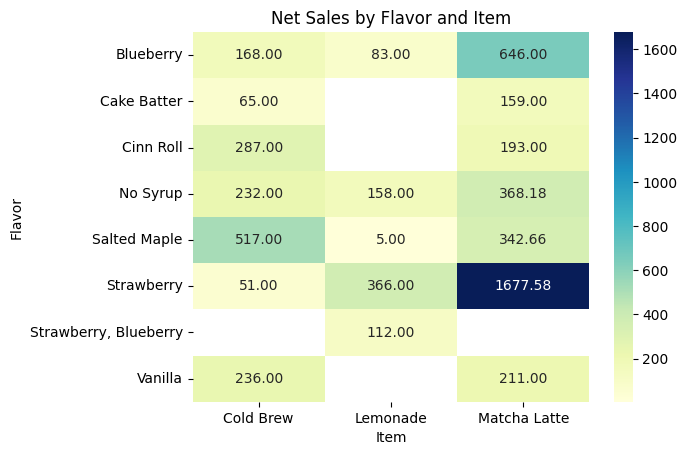

In [227]:
pivot = drink_df.pivot_table(
    index="Flavor",
    columns="Item",
    values="Net_Sales",
    aggfunc="sum"
)
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Net Sales by Flavor and Item")
plt.xlabel("Item")
plt.ylabel("Flavor")
plt.show()

The heatmap reveals that strawberry was the most popular flavor for both matcha lattes and lemonades, while salted maple was the most popular flavor for cold brews.

### 4.2 Milk Preferences

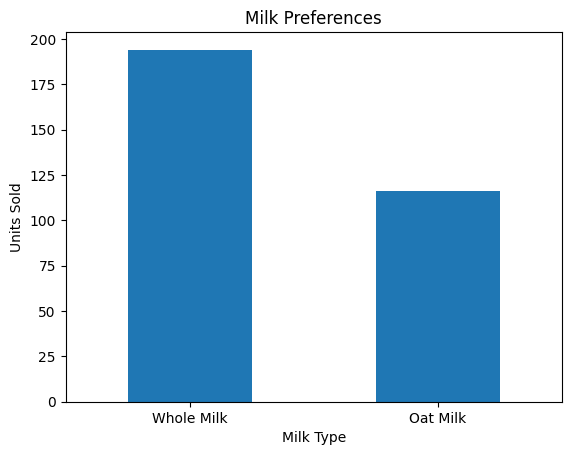

In [228]:
milk_df = drink_df[drink_df["Base"].isin(["Whole Milk", "Oat Milk"])]

milk_pref = milk_df.groupby("Base")["Qty"].sum().sort_values(ascending=False)

milk_pref.plot(kind="bar")
plt.title("Milk Preferences")
plt.xlabel("Milk Type")
plt.ylabel("Units Sold")
plt.xticks(rotation=0)
plt.show()

Whole milk was selected more frequently than oat milk, suggesting that customers generally preferred traditional dairy options.

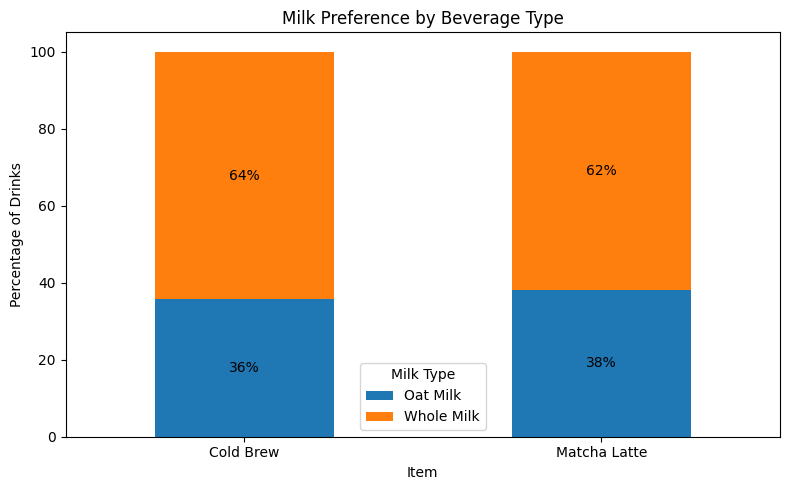

In [229]:
# Milk Preference by Beverage Type
milk_item_pct = (
    drink_df[drink_df["Item"].isin(["Matcha Latte", "Cold Brew"])]
      .query('Base in ["Whole Milk", "Oat Milk"]')
      .groupby(["Item", "Base"])["Qty"]
      .sum()
      .unstack(fill_value=0)
)

# Convert to percentages
milk_item_pct = milk_item_pct.div(
    milk_item_pct.sum(axis=1), axis=0
) * 100

ax = milk_item_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Milk Preference by Beverage Type")
plt.ylabel("Percentage of Drinks")
plt.xlabel("Item")
plt.xticks(rotation=0)
plt.legend(title="Milk Type")

for container in ax.containers:
    labels = [f"{v:.0f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center")

plt.tight_layout()
plt.show()

### 4.3 Cold Foam Preferences

In [233]:
drink_df.groupby("Cold_Foam").agg(
    Net_Sales=("Net_Sales", "sum"),
    Qty=("Qty", "sum")).abs().sort_values("Net_Sales", ascending=False) 

,Net_Sales,Qty
Cold_Foam,,
True,3257.50,400.0
False,2619.92,426.0


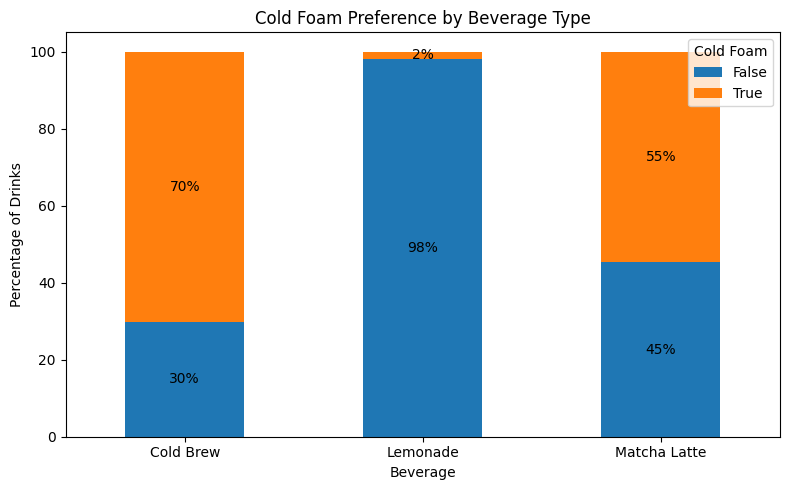

In [238]:
foam_by_item = (
    drink_df.groupby(["Item", "Cold_Foam"])["Qty"]
    .sum()
    .unstack(fill_value=0)
)

foam_by_item_pct = foam_by_item.div(foam_by_item.sum(axis=1), axis=0) * 100

ax = foam_by_item_pct.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Cold Foam Preference by Beverage Type")
plt.ylabel("Percentage of Drinks")
plt.xlabel("Beverage")
plt.xticks(rotation=0)
plt.legend(title="Cold Foam")

for container in ax.containers:
    labels = [f"{v:.0f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center")

plt.tight_layout()
plt.show()

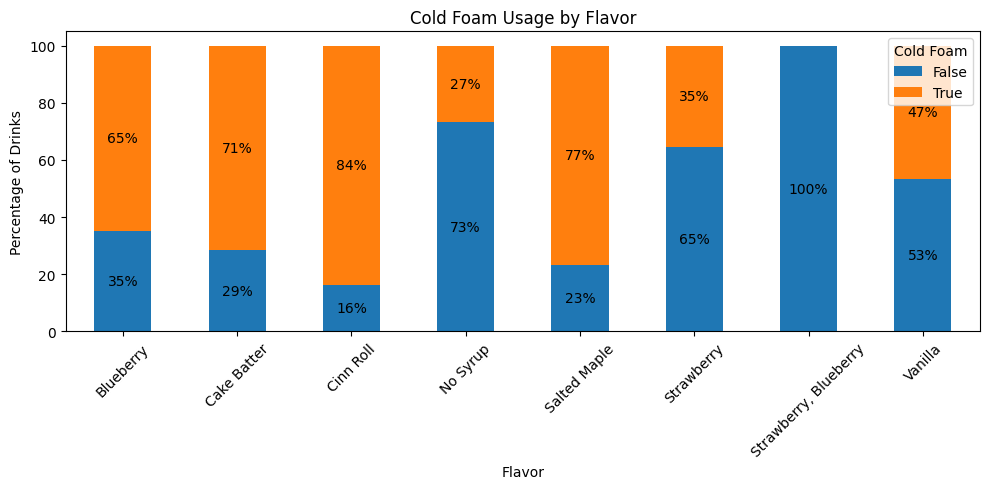

In [239]:
foam_by_flavor = (
    drink_df.groupby(["Flavor", "Cold_Foam"])["Qty"]
    .sum()
    .unstack(fill_value=0)
)

foam_by_flavor_pct = foam_by_flavor.div(foam_by_flavor.sum(axis=1), axis=0) * 100

ax = foam_by_flavor_pct.plot(kind="bar", stacked=True, figsize=(10,5))

plt.title("Cold Foam Usage by Flavor")
plt.ylabel("Percentage of Drinks")
plt.xlabel("Flavor")
plt.xticks(rotation=45)
plt.legend(title="Cold Foam")

for container in ax.containers:
    labels = [f"{v:.0f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center")

plt.tight_layout()
plt.show()

## Section 5: Event and Operational Analysis

### 5.1 Revenue by Event Type

In [243]:
df.groupby("Event_Type")["Net_Sales"].sum()

Event_Type
Delivery      57.00
Market      4743.42
Popup       1371.00
Name: Net_Sales, dtype: float64

In [244]:
# Average daily sales by event type
daily_sales = (
    df.groupby(["Date", "Event_Type"])["Net_Sales"]
      .sum()
      .reset_index()
)

avg_sales = (
    daily_sales.groupby("Event_Type")["Net_Sales"]
    .mean()
    .sort_values(ascending=False)
)

avg_sales

Event_Type
Market      1185.855
Popup        457.000
Delivery      57.000
Name: Net_Sales, dtype: float64

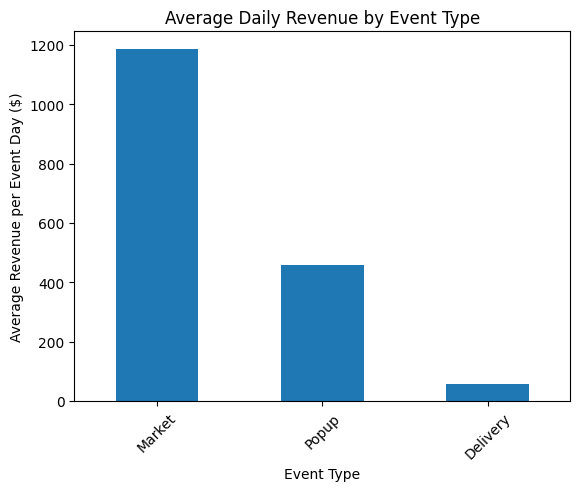

In [245]:
avg_sales.plot(kind="bar")
plt.title("Average Daily Revenue by Event Type")
plt.ylabel("Average Revenue per Event Day ($)")
plt.xlabel("Event Type")
plt.xticks(rotation=45)
plt.show()

### 5.2 Revenue by Market Location

Note: Market locations differ in external setup costs (Manteo and First Flight: $25 entry fee; Soundside: $160 entry fee), which are not included in the dataset. Therefore, revenue comparisons reflect observed sales performance only and do not account for differences in operating costs or market scale.


In [251]:
# Filter dataset to only include market locations
market_locations = ["Manteo", "First Flight", "Soundside"]

market_df = df[df["Location"].isin(market_locations)]

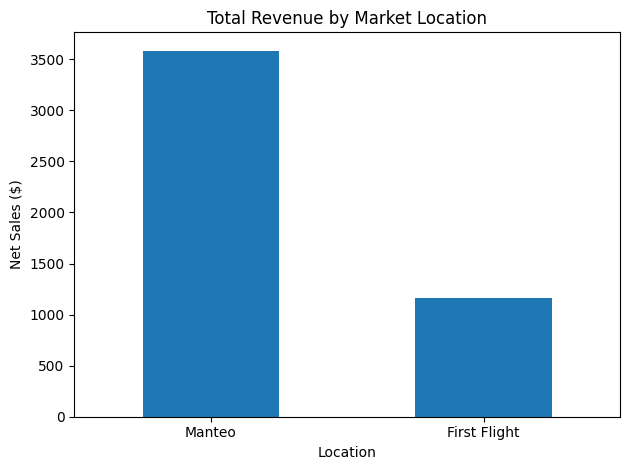

In [252]:
# Total revenue by market location
location_revenue = (
    market_df.groupby("Location")["Net_Sales"]
    .sum()
    .sort_values(ascending=False)
)

location_revenue.plot(kind="bar")

plt.title("Total Revenue by Market Location")
plt.xlabel("Location")
plt.ylabel("Net Sales ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

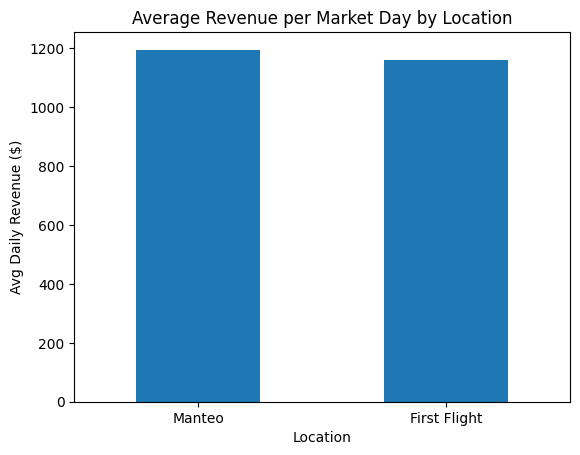

In [250]:
# Average daily revenue by market location
daily_market = (
    market_df.groupby(["Date", "Location"])["Net_Sales"]
    .sum()
    .reset_index()
)

avg_market = (
    daily_market.groupby("Location")["Net_Sales"]
    .mean()
    .sort_values(ascending=False)
)

avg_market.plot(kind="bar")
plt.title("Average Revenue per Market Day by Location")
plt.ylabel("Avg Daily Revenue ($)")
plt.xlabel("Location")
plt.xticks(rotation=0)
plt.show()

### 5.3 Time-Based Patterns

In [203]:
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour

/var/folders/w2/4nk24xz14yg09dbpyrxdn4c80000gn/T/ipykernel_73939/816105062.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour


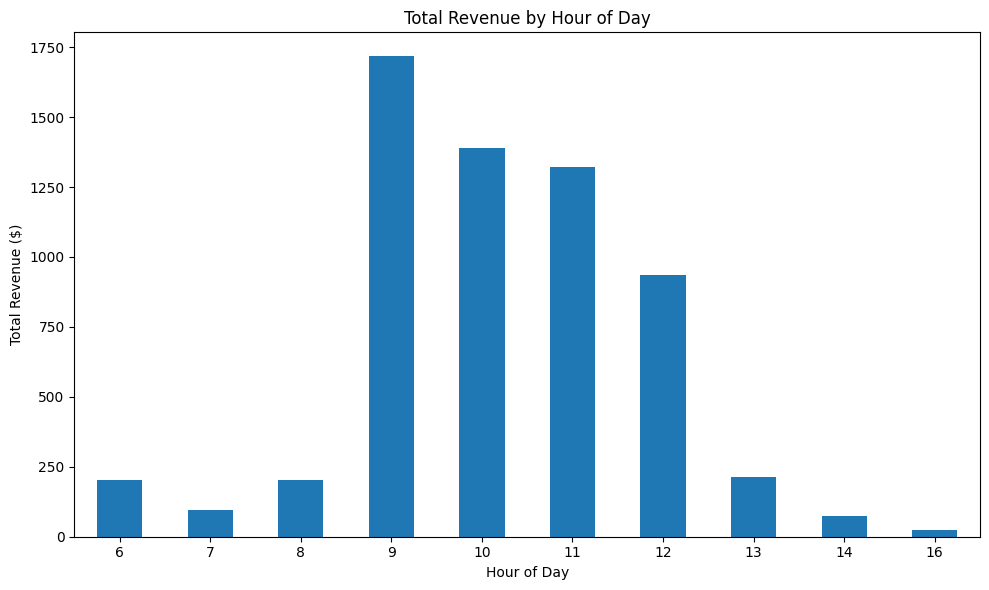

In [253]:
df.groupby("Hour")["Net_Sales"].sum().plot(kind="bar", figsize=(10, 6))
plt.title("Total Revenue by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The peak sales hours are from 9am-1pm, which the time frame in which all of the markets occur. In that, the first hour of the markets, 9-10am, generates the most revenue.

## Section 6: External Factors

In [ ]:
# temperature / weather impacts on revenue and item type

## Section 7: Key Insights and Recommendations

Key Findings

Matcha Latte is the primary revenue driver.

Customers exhibit strong preference for flavored beverages.

Markets outperform other event formats on average.

Sales are concentrated during morning hours.

Business Recommendations

Prioritize inventory for Matcha Lattes and strawberry syrup.

Expand high-performing market events.

Schedule staffing around peak morning demand.